In [2]:
# ==============================
# COMPLETE COMPONENT-BASED ENERGY MODEL
# ==============================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATASET
data = pd.read_excel("energy consumption dataset.xlsx")

# 3. DEFINE INPUT FEATURES (NO DATA LEAKAGE)
feature_cols = [
    "Hr",
    "Occ_%",
    "Out_Temp",
    "Day_Type",
    "Season"
]

# 4. DEFINE ENERGY COMPONENT TARGETS
component_targets = {
    "HVAC": "HVAC_kWh",
    "Lighting": "Lighting_kWh",
    "IT": "IT_Equipment_kWh",
    "Elevator": "Elevator_kWh",
    "AirPurifier": "Air_Purifier_kWh"
}

# 5. PREPROCESSING PIPELINE
numeric_features = ["Hr", "Occ_%", "Out_Temp"]
categorical_features = ["Day_Type", "Season"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

# 6. FUNCTION TO TRAIN A COMPONENT MODEL
def train_component_model(target_column):

    X = data[feature_cols]
    y = data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("regressor", RandomForestRegressor(
                n_estimators=200,
                random_state=42
            ))
        ]
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return model, mae, rmse, r2

# 7. TRAIN MODELS FOR ALL ENERGY COMPONENTS
models = {}
results = {}

for name, target in component_targets.items():
    model, mae, rmse, r2 = train_component_model(target)
    models[name] = model
    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# 8. DISPLAY COMPONENT MODEL PERFORMANCE
results_df = pd.DataFrame(results).T
print("Component Model Performance:")
print(results_df)

# 9. PREDICT ENERGY COMPONENTS FOR FULL DATASET
X_all = data[feature_cols]
predicted_components = pd.DataFrame(index=data.index)

for name, model in models.items():
    predicted_components[name + "_Pred"] = model.predict(X_all)

# 10. AGGREGATE PREDICTED TOTAL ENERGY
predicted_components["Predicted_Total_Energy"] = (
    predicted_components["HVAC_Pred"] +
    predicted_components["Lighting_Pred"] +
    predicted_components["IT_Pred"] +
    predicted_components["Elevator_Pred"] +
    predicted_components["AirPurifier_Pred"]
)

# 11. FINAL EVALUATION — TOTAL ENERGY
actual_total = data["Total_Energy_kWh"]
pred_total = predicted_components["Predicted_Total_Energy"]

mae_total = mean_absolute_error(actual_total, pred_total)
rmse_total = np.sqrt(mean_squared_error(actual_total, pred_total))
r2_total = r2_score(actual_total, pred_total)

print("\nAggregated Total Energy Performance:")
print("MAE :", mae_total)
print("RMSE:", rmse_total)
print("R2  :", r2_total)

# 12. SAVE FINAL RESULTS (OPTIONAL)
final_output = pd.concat([data, predicted_components], axis=1)
final_output.to_csv("predicted_energy_results.csv", index=False)

print("\nProcess completed successfully. Results saved to predicted_energy_results.csv")


Component Model Performance:
                  MAE      RMSE        R2
HVAC         2.320097  4.388496  0.999790
Lighting     0.004201  0.020282  1.000000
IT           0.025962  0.125842  1.000000
Elevator     0.077535  0.370958  0.999997
AirPurifier  0.001167  0.004731  1.000000

Aggregated Total Energy Performance:
MAE : 1.2233354166671664
RMSE: 2.7682378119801228
R2  : 0.9999950093875764

Process completed successfully. Results saved to predicted_energy_results.csv


In [3]:
def get_feature_importance(model, feature_names):
    regressor = model.named_steps["regressor"]
    importances = regressor.feature_importances_
    return pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)


In [4]:
encoded_feature_names = (
    numeric_features +
    list(
        models["HVAC"]
        .named_steps["preprocessing"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)


In [5]:
feature_importance_results = {}

for component, model in models.items():
    fi = get_feature_importance(model, encoded_feature_names)
    feature_importance_results[component] = fi
    print(f"\nFeature Importance for {component}:")
    print(fi)



Feature Importance for HVAC:
            Feature  Importance
1             Occ_%    0.389150
2          Out_Temp    0.328777
4     Season_Summer    0.200428
0                Hr    0.051295
3  Day_Type_Weekend    0.019214
5     Season_Winter    0.011137

Feature Importance for Lighting:
            Feature    Importance
1             Occ_%  5.645100e-01
0                Hr  4.354328e-01
3  Day_Type_Weekend  5.711948e-05
5     Season_Winter  4.352183e-08
2          Out_Temp  2.429329e-15
4     Season_Summer  1.703935e-15

Feature Importance for IT:
            Feature    Importance
1             Occ_%  9.868651e-01
0                Hr  1.304361e-02
3  Day_Type_Weekend  9.133569e-05
2          Out_Temp  1.899964e-16
4     Season_Summer  1.449942e-16
5     Season_Winter  1.187154e-16

Feature Importance for Elevator:
            Feature    Importance
1             Occ_%  9.510320e-01
0                Hr  4.866956e-02
3  Day_Type_Weekend  2.983169e-04
2          Out_Temp  1.383542e-07
4   

In [ ]:
# ==============================
# EFFICIENCY CLASSIFICATION MODEL
# ==============================

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. DEFINE FEATURES FOR CLASSIFICATION
classification_features = [
    "Hr",
    "Occ_%",
    "Out_Temp",
    "Day_Type",
    "Season",
    "Total_Energy_kWh",
    "Expected_Energy_kWh",
    "AEI"
]

X_cls = data[classification_features]
y_cls = data["Efficiency_Label_Clean"]  # use cleaned labels

# 2. ENCODE TARGET LABELS
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_cls)

# 3. PREPROCESSING (NUMERIC + CATEGORICAL)
numeric_features_cls = [
    "Hr",
    "Occ_%",
    "Out_Temp",
    "Total_Energy_kWh",
    "Expected_Energy_kWh",
    "AEI"
]

categorical_features_cls = ["Day_Type", "Season"]

preprocessor_cls = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_cls),
        ("cat", OneHotEncoder(drop="first"), categorical_features_cls)
    ]
)

# 4. TRAIN–TEST SPLIT
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# 5. BUILD CLASSIFICATION PIPELINE
clf = Pipeline(
    steps=[
        ("preprocessing", preprocessor_cls),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# 6. TRAIN MODEL
clf.fit(X_train_cls, y_train_cls)

# 7. PREDICT
y_pred_cls = clf.predict(X_test_cls)

# 8. EVALUATION
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cls, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_cls))


Accuracy: 1.0

Classification Report:
                      precision    recall  f1-score   support

           Efficient       1.00      1.00      1.00        22
Moderately Efficient       1.00      1.00      1.00       122

            accuracy                           1.00       144
           macro avg       1.00      1.00      1.00       144
        weighted avg       1.00      1.00      1.00       144


Confusion Matrix:
[[ 22   0]
 [  0 122]]


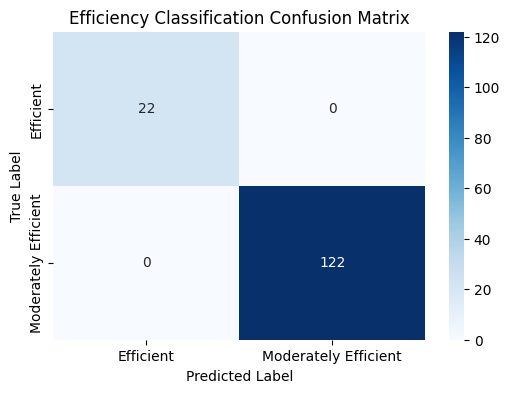

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Efficiency Classification Confusion Matrix")
plt.show()


In [ ]:
misclassified = X_test_cls[y_test_cls != y_pred_cls]
misclassified


,Hr,Occ_%,Out_Temp,Day_Type,Season,Total_Energy_kWh,Expected_Energy_kWh,AEI


In [ ]:
import pandas as pd

data = pd.read_excel("energy consumption dataset.xlsx")



In [ ]:
predicted_components = pd.read_csv("predicted_energy_results.csv")


In [ ]:
actual_total = data["Total_Energy_kWh"]
pred_total = predicted_components["Predicted_Total_Energy"]


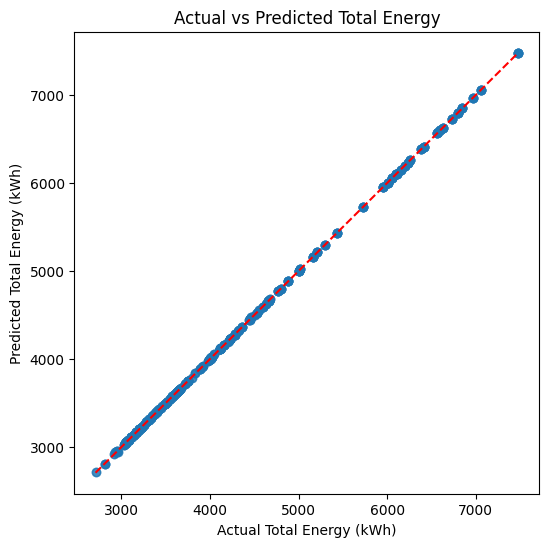

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(actual_total, pred_total, alpha=0.6)
plt.plot(
    [actual_total.min(), actual_total.max()],
    [actual_total.min(), actual_total.max()],
    'r--'
)

plt.xlabel("Actual Total Energy (kWh)")
plt.ylabel("Predicted Total Energy (kWh)")
plt.title("Actual vs Predicted Total Energy")
plt.show()


In [ ]:
residuals = actual_total - pred_total


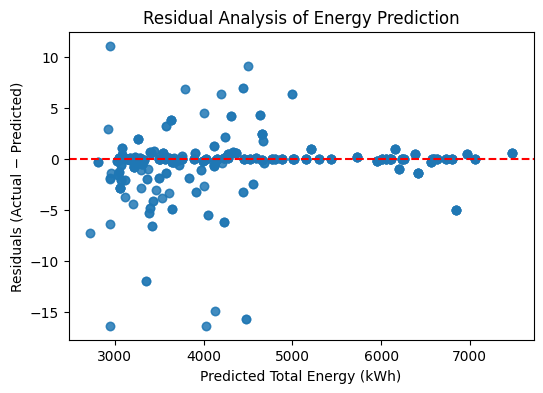

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(pred_total, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Total Energy (kWh)")
plt.ylabel("Residuals (Actual − Predicted)")
plt.title("Residual Analysis of Energy Prediction")
plt.show()


In [ ]:
component_means = {
    "HVAC": data["HVAC_kWh"].mean(),
    "Lighting": data["Lighting_kWh"].mean(),
    "IT Equipment": data["IT_Equipment_kWh"].mean(),
    "Elevator": data["Elevator_kWh"].mean(),
    "Air Purifier": data["Air_Purifier_kWh"].mean()
}



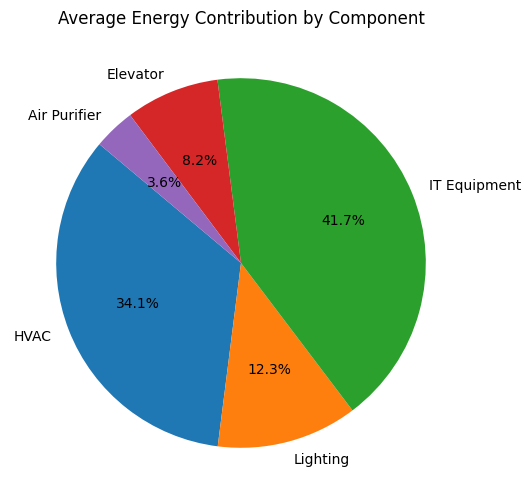

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(
    component_means.values(),
    labels=component_means.keys(),
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Average Energy Contribution by Component")
plt.show()


In [ ]:
hvac_fi = feature_importance_results["HVAC"]


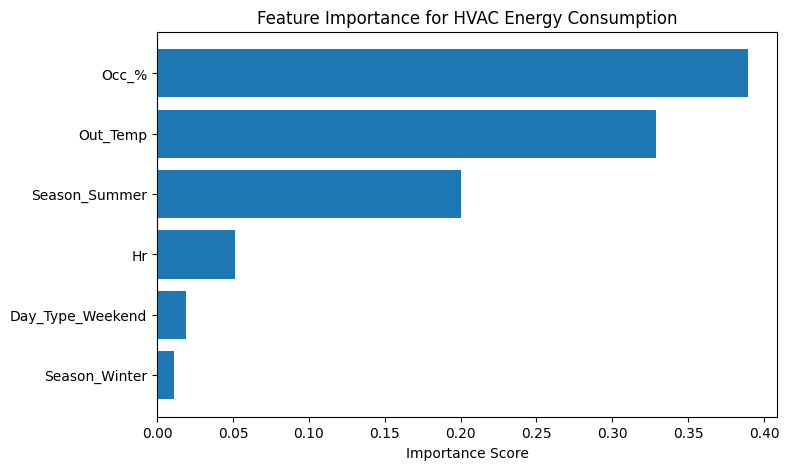

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(hvac_fi["Feature"], hvac_fi["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.title("Feature Importance for HVAC Energy Consumption")
plt.show()


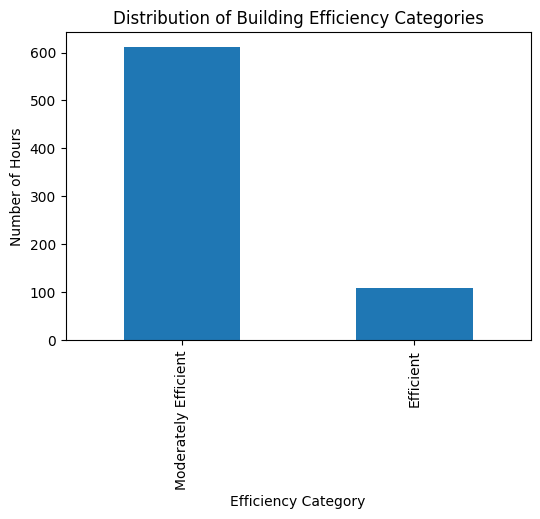

In [ ]:
import matplotlib.pyplot as plt

data["Efficiency_Label_Clean"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.xlabel("Efficiency Category")
plt.ylabel("Number of Hours")
plt.title("Distribution of Building Efficiency Categories")
plt.show()


In [ ]:
import pandas as pd

df = pd.read_excel("energy consumption dataset.xlsx")

df.head()


,Date,Day_Type,Hr,Season,Occ,Occ_%,Out_Temp,HVAC_Behavior,HVAC_kWh,Lighting_kWh,...,Air_Purifier_kWh,Elevator_kWh,Total_Energy_kWh,Expected_Energy_kWh,Grid_Energy_kWh,Carbon_Emission_kgCO2,AEI,Energy Deviation%,Efficiency label,Efficiency_Label_Clean
0,2025-01-01,Weekday,0,Winter,200,4.0,12,Heating_Dominant,1237.7,515.0,...,79.0,112.0,3049.7,2683.7,2592.2,2125.60,0.879988,12.001180,Moderately Efficient,Moderately Efficient
1,2025-01-01,Weekday,1,Winter,280,5.6,12,Heating_Dominant,1219.7,521.0,...,82.6,120.8,3080.5,2710.8,2618.4,2147.09,0.879987,12.001298,Moderately Efficient,Moderately Efficient
2,2025-01-01,Weekday,2,Winter,360,7.2,12,Heating_Dominant,1200.6,527.0,...,86.2,129.6,3110.2,2737.0,2643.7,2167.83,0.880008,11.999228,Moderately Efficient,Moderately Efficient
3,2025-01-01,Weekday,3,Winter,440,8.8,12,Heating_Dominant,1180.5,533.0,...,89.8,138.4,3138.9,2762.2,2668.1,2187.84,0.879990,12.001019,Moderately Efficient,Moderately Efficient
4,2025-01-01,Weekday,4,Winter,520,10.4,12,Heating_Dominant,1159.4,539.0,...,93.4,147.2,3166.6,2786.6,2691.6,2207.11,0.879997,12.000253,Moderately Efficient,Moderately Efficient


In [ ]:
## 6. Stress Testing Under Operational Perturbations
### Stress Case 1: Reduced Occupancy Scenario

import pandas as pd
import numpy as np




df_noise = df.copy()

# Energy columns in your dataset
energy_cols = [
    'HVAC_kWh',
    'Lighting_kWh',
    'IT_Equipment_kWh',
    'Air_Purifier_kWh',
    'Elevator_kWh'
]

# Add ±5% noise
for col in energy_cols:
    noise = np.random.normal(1, 0.05, size=len(df_noise))
    df_noise[col] = df_noise[col] * noise

# Recalculate total energy after noise
df_noise['Total_Energy_kWh'] = df_noise[energy_cols].sum(axis=1)


In [ ]:

### Stress Case 2: Elevated Environmental Load
df_extreme = df.copy()

# Increase outdoor temperature & occupancy
df_extreme['Out_Temp'] = df_extreme['Out_Temp'] * 1.15
df_extreme['Occ'] = df_extreme['Occ'] * 1.2
df_extreme['Occ_%'] = df_extreme['Occ_%'] * 1.2


In [ ]:
import pandas as pd

df_industry = pd.read_excel("energy consumption dataset.xlsx")


In [ ]:
## Industry Layer: Enterprise Energy Decision Framework
##The objective is not optimal prediction, but reliable decision support under
##changing operational regimes.


# --- Industry-aware temperature interaction feature ---


# Temperature impact on HVAC (industry realistic)
df_industry['HVAC_Temp_Interaction'] = (
    df_industry['HVAC_kWh'] * df_industry['Out_Temp']
)


def assign_industry_type(row):
    # IT / Office buildings
    if row['IT_Equipment_kWh'] > row['Lighting_kWh'] and row['Occ_%'] < 60:
        return 'IT_Office'

    # Research / Lab type buildings
    elif row['Air_Purifier_kWh'] > 1.5 and row['HVAC_kWh'] > 30:
        return 'Research_Lab'

    # Commercial / High-traffic buildings
    else:
        return 'Commercial'

df_industry['Industry_Type'] = df_industry.apply(assign_industry_type, axis=1)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_industry = LabelEncoder()
df_industry['Industry_Type_Encoded'] = le_industry.fit_transform(
    df_industry['Industry_Type']
)

# Check mapping
dict(zip(le_industry.classes_, le_industry.transform(le_industry.classes_)))


{'IT_Office': np.int64(0), 'Research_Lab': np.int64(1)}

In [ ]:
### Feature classification in industry framework

features_industry = [
    'Occ_%',
    'Out_Temp',
    'HVAC_kWh',
    'Lighting_kWh',
    'IT_Equipment_kWh',
    'Air_Purifier_kWh',
    'Elevator_kWh'
]

X_ind = df_industry[features_industry]
y_ind = df_industry['Industry_Type_Encoded']


In [ ]:
# Train test and split of data in industry layer
from sklearn.model_selection import train_test_split

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_ind, y_ind, test_size=0.2, random_state=42, stratify=y_ind
)


In [ ]:
## Random forest Classifier in industry layer

from sklearn.ensemble import RandomForestClassifier

industry_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

industry_model.fit(X_train_i, y_train_i)


RandomForestClassifier(random_state=42)

In [ ]:
## Confused matrix of industry layer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_i = industry_model.predict(X_test_i)

print("Industry Prediction Accuracy:", accuracy_score(y_test_i, y_pred_i))
print("\nClassification Report:\n", classification_report(y_test_i, y_pred_i))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_i, y_pred_i))


Industry Prediction Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       1.00      1.00      1.00        38

    accuracy                           1.00       144
   macro avg       1.00      1.00      1.00       144
weighted avg       1.00      1.00      1.00       144


Confusion Matrix:
 [[106   0]
 [  0  38]]


In [ ]:
## Generation of feature importance in the industry layer

import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': features_industry,
    'Importance': industry_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance


,Feature,Importance
6,Elevator_kWh,0.274730
5,Air_Purifier_kWh,0.237319
0,Occ_%,0.228116
4,IT_Equipment_kWh,0.221675
3,Lighting_kWh,0.029512
2,HVAC_kWh,0.008648
1,Out_Temp,0.000000
